In [1]:
import torch

file_path = "/mnt/abka03/Projects/xl-vlms/outputs/run_test_tank/concept/snmf/combined_concept_snmf_raw.pth"
data1 = torch.load(file_path, map_location='cpu')
print(data1.keys())
print(data1['concepts'].shape)
print(data1['image_grounding_bboxes'])
print(data1['image_grounding_predictions'])
print(data1['text_grounding'])
print(data1['image_grounding_paths'])
print(data1['concept_names'])

dict_keys(['concepts', 'concept_names', 'activations', 'decomposition_method', 'text_grounding', 'image_grounding_paths', 'image_grounding_bboxes', 'image_grounding_masks', 'analysis_model', 'image_grounding_predictions'])
torch.Size([5, 3584])
[[[18, 67, 184, 184], [112, 82, 184, 184], [30, 119, 184, 184], [22, 22, 184, 184], [24, 94, 184, 184], [21, 21, 184, 184], [22, 22, 184, 184], [22, 82, 184, 184], [32, 32, 184, 184], [30, 30, 184, 184]], [[130, 32, 184, 184], [22, 22, 184, 184], [13, 13, 184, 184], [22, 82, 184, 184], [18, 67, 184, 184], [131, 128, 184, 184], [18, 18, 184, 184], [22, 22, 184, 184], [113, 22, 184, 184], [32, 32, 184, 184]], [[22, 22, 184, 184], [22, 22, 184, 184], [18, 18, 184, 184], [26, 26, 184, 184], [22, 82, 184, 184], [22, 83, 184, 184], [98, 52, 184, 184], [22, 84, 184, 184], [22, 22, 184, 184], [106, 18, 184, 184]], [[21, 21, 184, 184], [22, 22, 184, 184], [22, 22, 184, 184], [22, 82, 184, 184], [22, 22, 184, 184], [30, 30, 184, 184], [22, 22, 184, 184], 

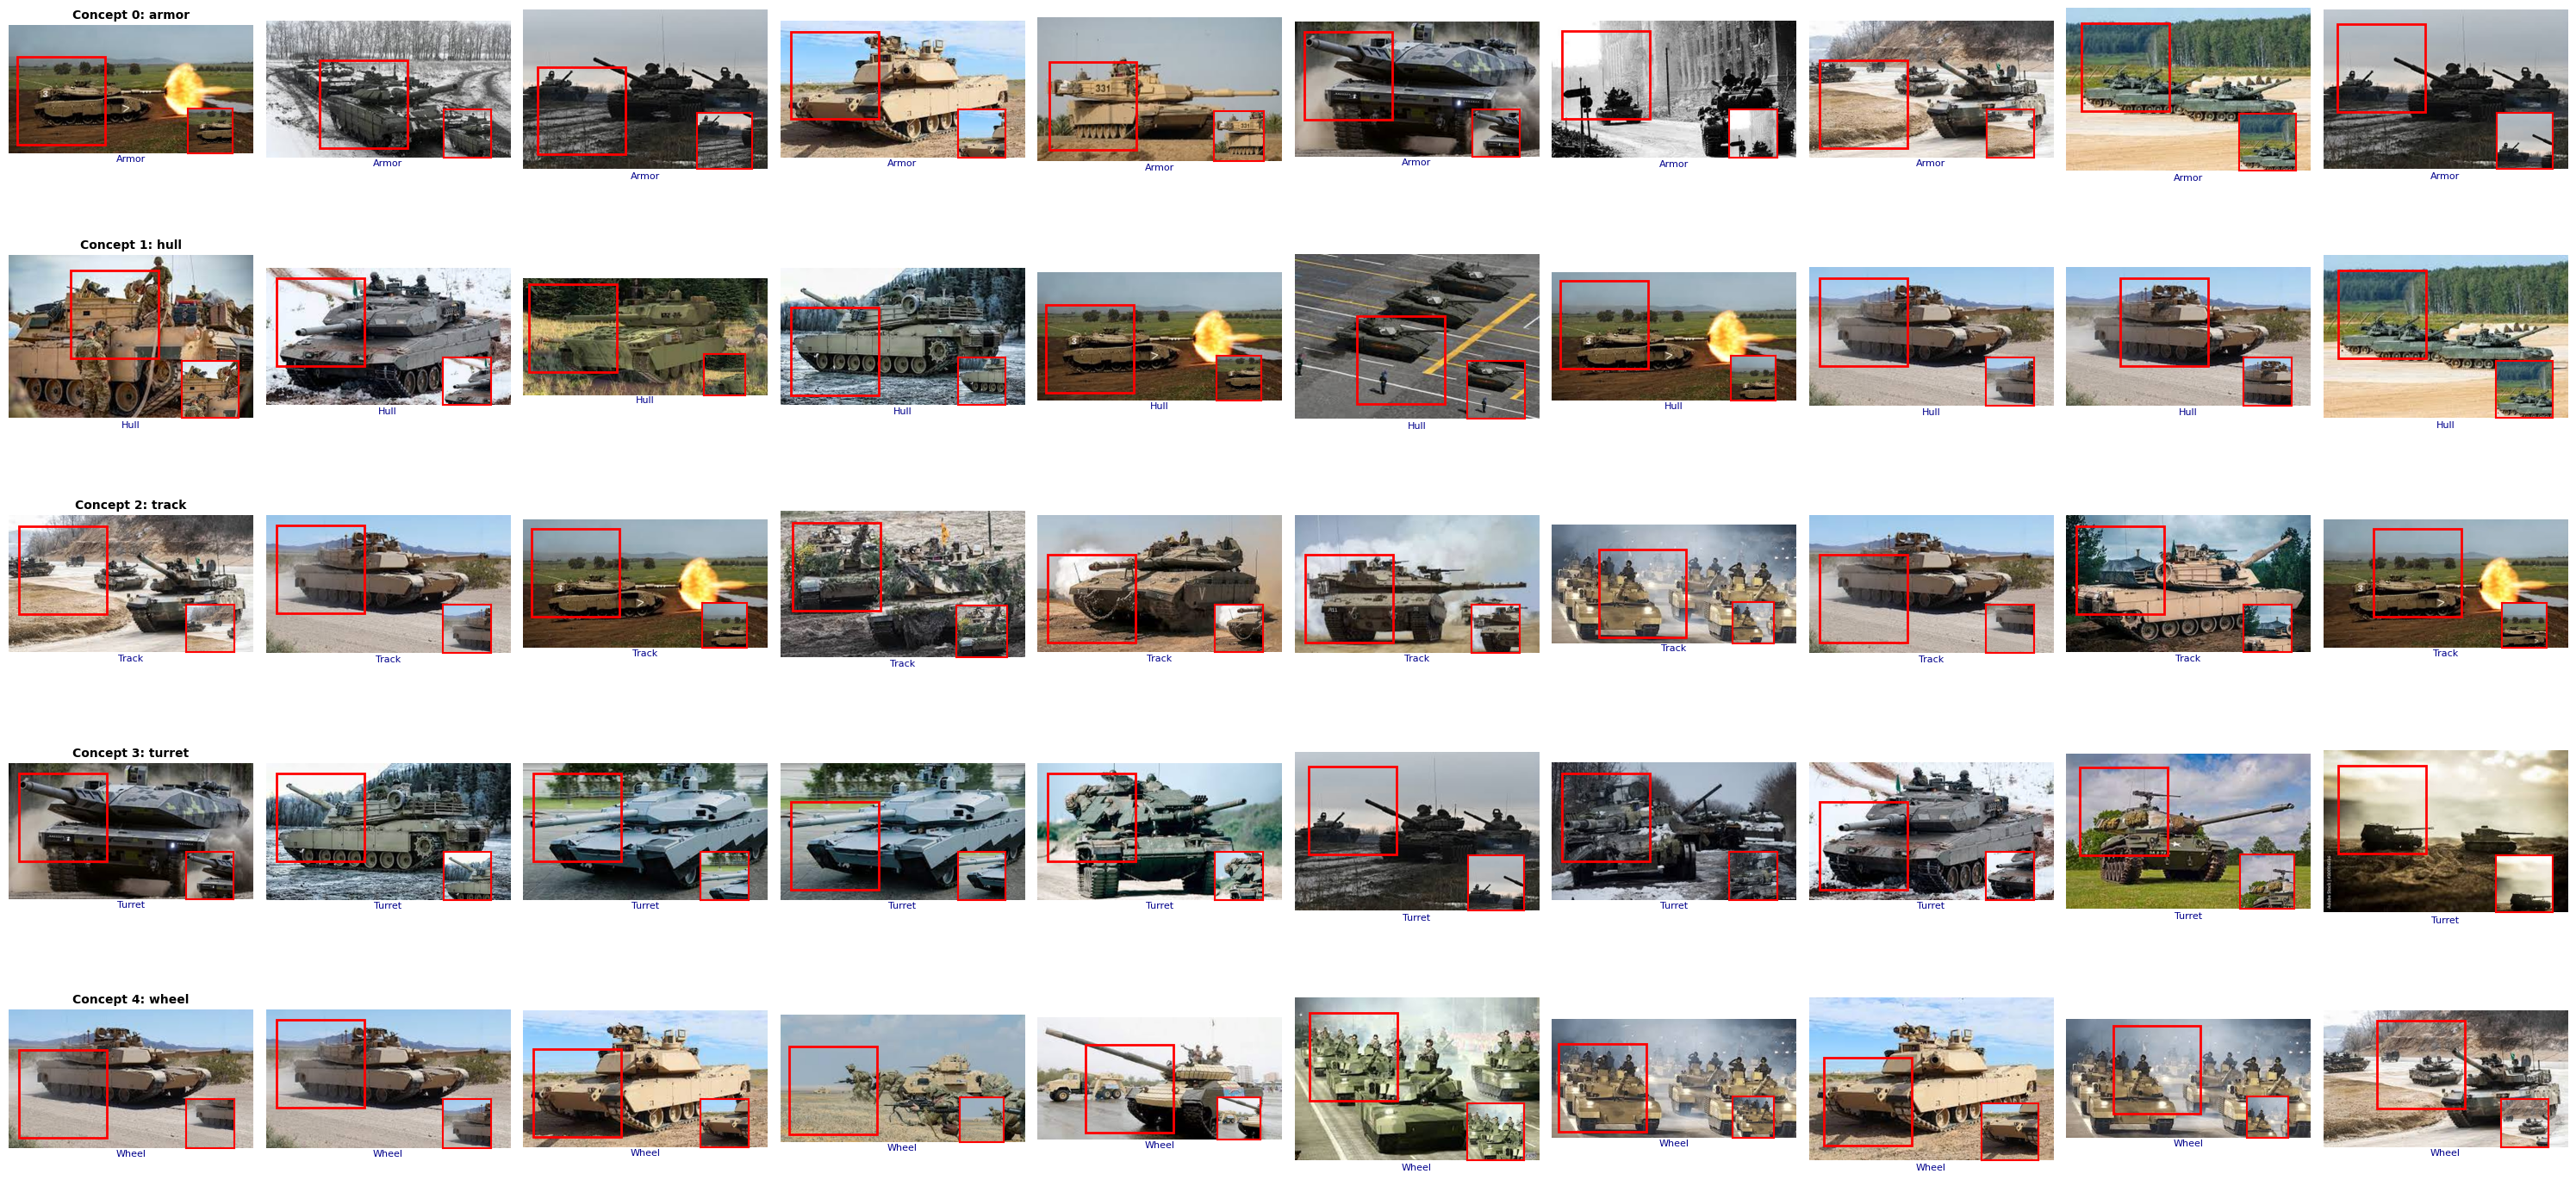

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.patches import Rectangle

# Bboxes are stored in IMAGE_SIZE_WIDTH-wide space with aspect ratio preserved.
# We must resize images the same way — width=IMAGE_SIZE_WIDTH, height proportional.
# Using a fixed square (e.g. 512×512) stretches the height and displaces bboxes.
BBOX_IMAGE_WIDTH = 512  # from .env cell; falls back to 512 if not set

paths_all         = data1.get("image_grounding_paths", [])
bboxes_all        = data1.get("image_grounding_bboxes", [])
preds_all         = data1.get("image_grounding_predictions", [])
concept_names_all = data1.get("concept_names", [])

def _safe_get(arr, i, j, default=None):
    try:
        return arr[i][j]
    except Exception:
        return default

def _to_list_if_tensor(x):
    if hasattr(x, "detach") and hasattr(x, "cpu"):
        return x.detach().cpu().numpy().tolist()
    return x

def _resize_keep_aspect(img, target_width):
    """Resize so width == target_width, height scaled proportionally."""
    orig_w, orig_h = img.size
    scale  = target_width / orig_w
    new_h  = max(1, int(round(orig_h * scale)))
    resample = getattr(getattr(Image, "Resampling", Image), "LANCZOS", Image.BICUBIC)
    return img.resize((target_width, new_h), resample=resample)

num_concepts = len(paths_all)
if num_concepts == 0:
    raise ValueError("No image_grounding_paths found in data1")

num_cols = max((len(row) for row in paths_all if isinstance(row, list)), default=0)
if num_cols == 0:
    raise ValueError("image_grounding_paths is empty or malformed")

fig_w = max(14, num_cols * 3.0)
fig_h = max(8,  num_concepts * 3.0)
fig, axes = plt.subplots(num_concepts, num_cols, figsize=(fig_w, fig_h), squeeze=False)

for i in range(num_concepts):
    row_concept_name = ""
    if i < len(concept_names_all) and isinstance(concept_names_all[i], list) and concept_names_all[i]:
        row_concept_name = str(concept_names_all[i][0])

    for j in range(num_cols):
        ax   = axes[i, j]
        ax.axis("off")

        img_path = _safe_get(paths_all,  i, j, None)
        bbox     = _to_list_if_tensor(_safe_get(bboxes_all, i, j, None))
        pred     = _safe_get(preds_all,  i, j, "")

        if not img_path or not isinstance(img_path, str) or not os.path.exists(img_path):
            ax.text(0.5, 0.5, "Missing image", ha="center", va="center", fontsize=9)
            continue

        try:
            img    = Image.open(img_path).convert("RGB")
            # Resize width→BBOX_IMAGE_WIDTH, preserve aspect ratio — matches bbox coordinate space
            img    = _resize_keep_aspect(img, BBOX_IMAGE_WIDTH)
            img_np = np.array(img)
            ax.imshow(img_np)

            # Draw crop region
            if isinstance(bbox, (list, tuple)) and len(bbox) == 4:
                x, y, w, h = [float(v) for v in bbox]
                rect = Rectangle((x, y), w, h, linewidth=2.0, edgecolor="red", facecolor="none")
                ax.add_patch(rect)

                # Also show the actual crop inset (bottom-right corner of the axis)
                crop = img_np[int(y):int(y+h), int(x):int(x+w)]
                if crop.size > 0:
                    inset = ax.inset_axes([0.65, 0.0, 0.35, 0.35])
                    inset.imshow(crop)
                    inset.set_xticks([])
                    inset.set_yticks([])
                    for spine in inset.spines.values():
                        spine.set_edgecolor("red")
                        spine.set_linewidth(1.5)

            pred_text = str(_to_list_if_tensor(pred))
            ax.text(0.5, -0.06, pred_text, transform=ax.transAxes,
                    ha="center", fontsize=8, color="darkblue")

        except Exception as e:
            ax.text(0.5, 0.5, f"Error loading image\n{e}",
                    ha="center", va="center", fontsize=8)

        if j == 0:
            title = f"Concept {i}: {row_concept_name}" if row_concept_name else f"Concept {i}"
            ax.set_title(title, fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

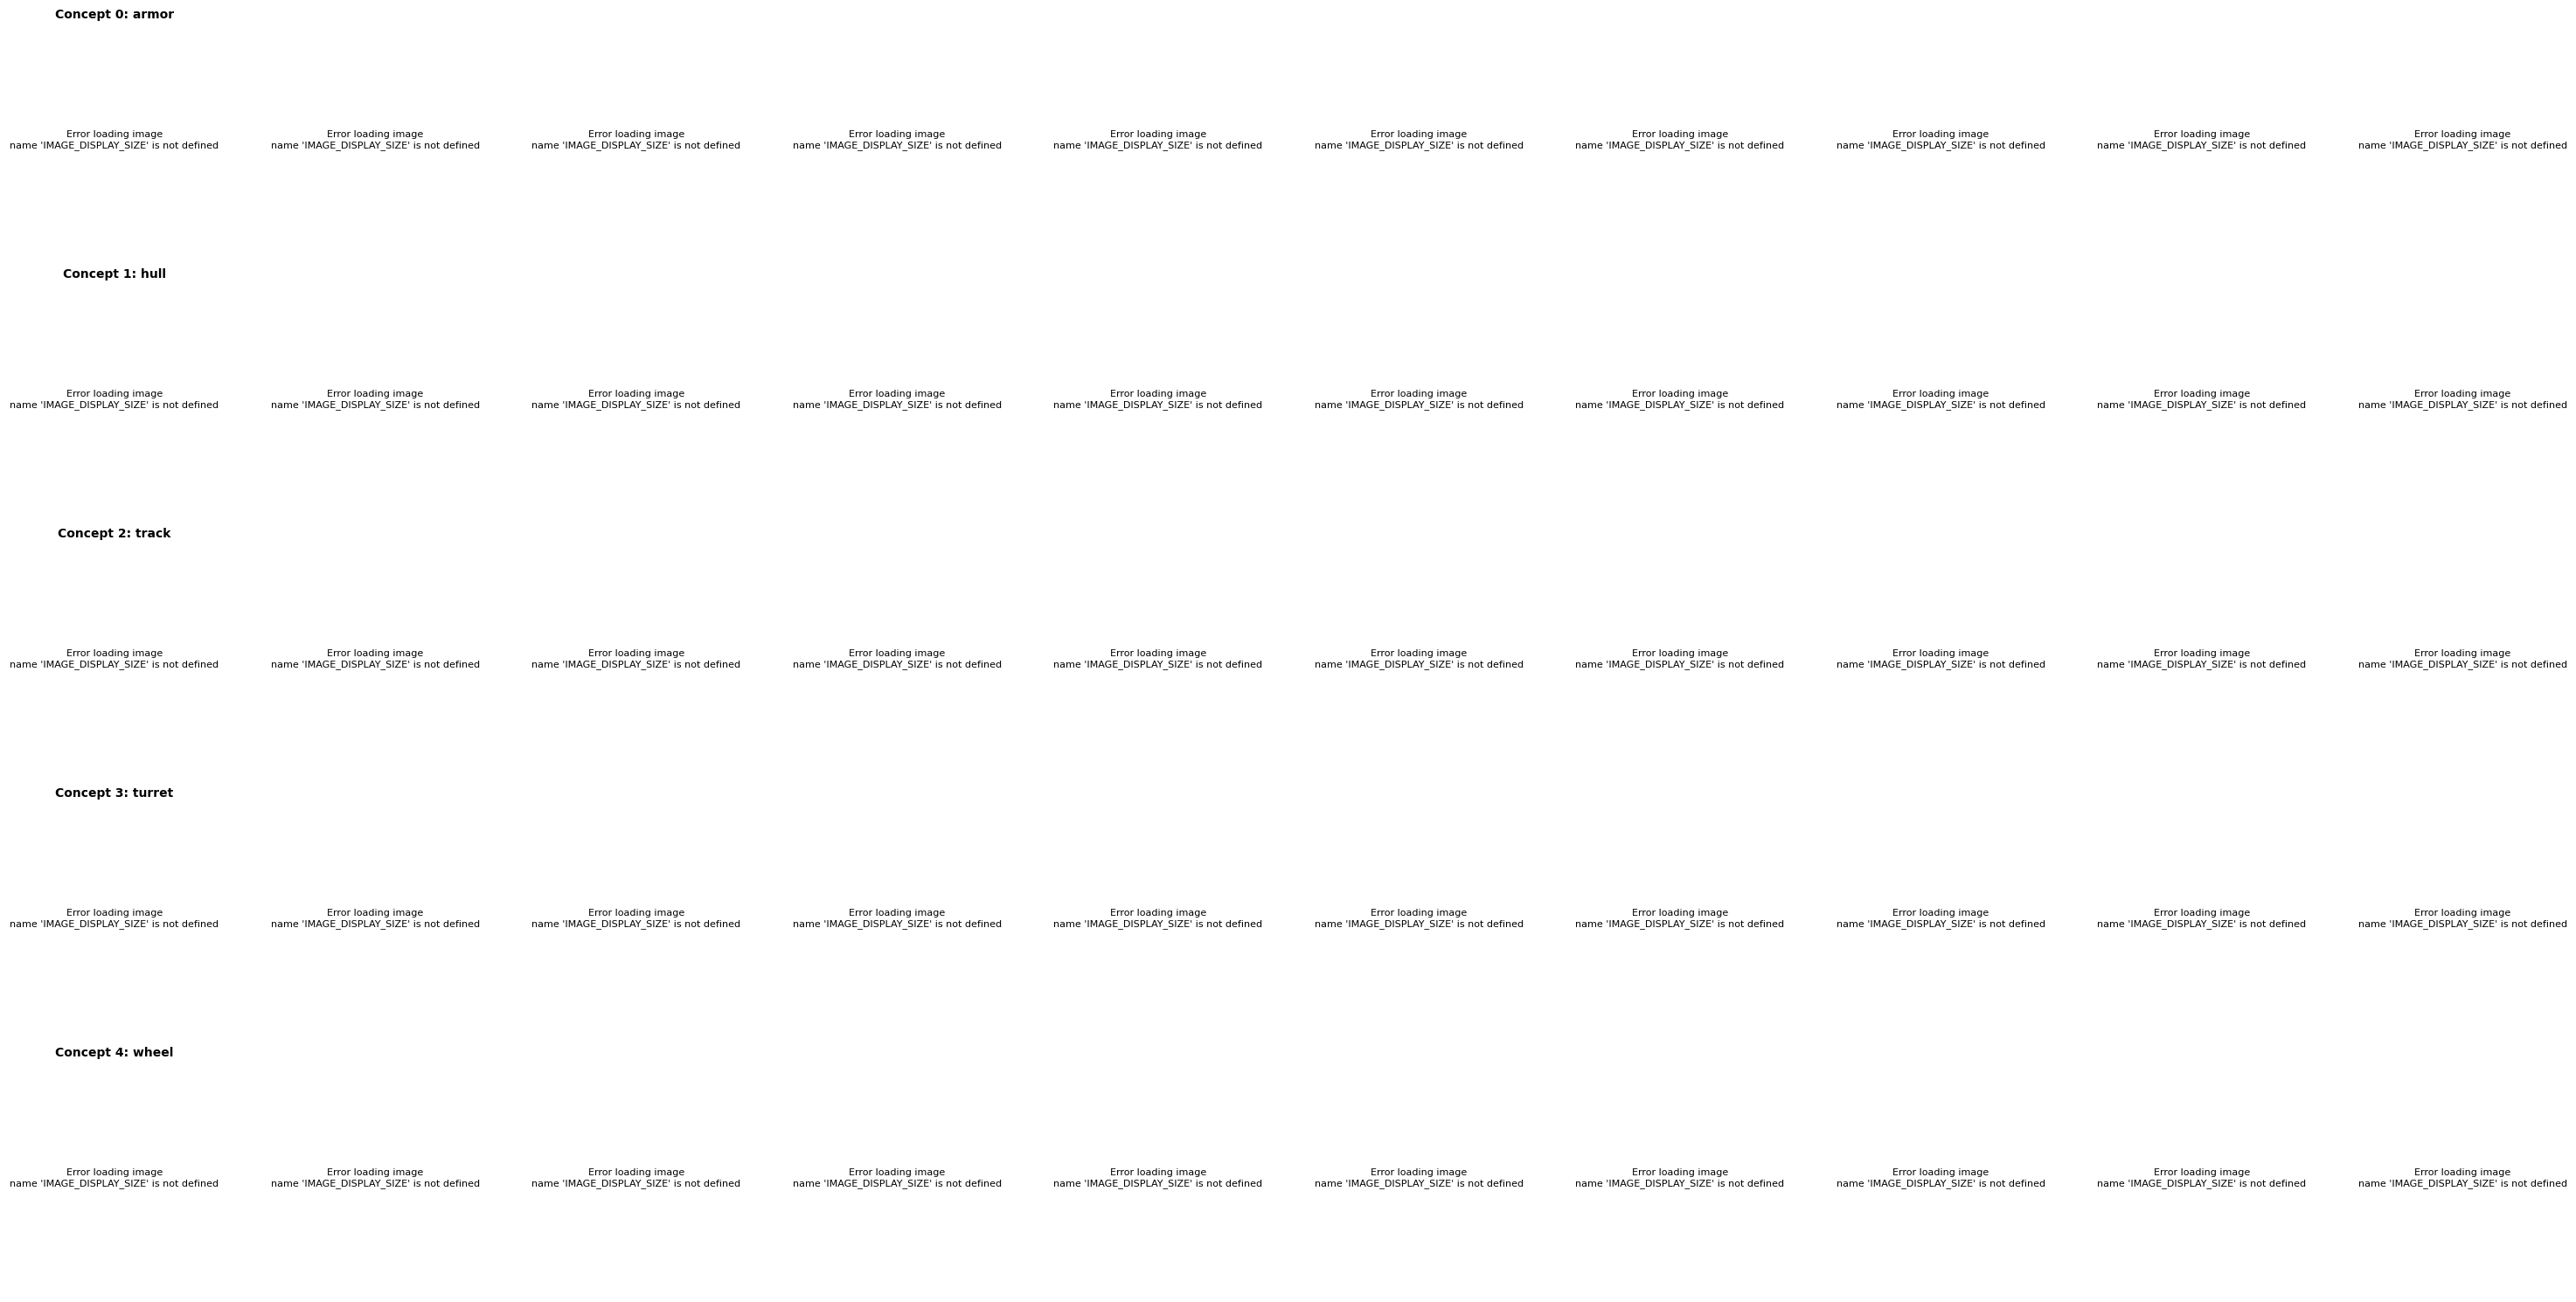

In [3]:
# Overlay RLE masks (if present) on each image — robust/debug version
# Ensure project root is on sys.path so `src` is importable in notebooks
import sys
from pathlib import Path
repo_root = Path.cwd().resolve()
for candidate in [repo_root, *repo_root.parents]:
    if (candidate / 'src').is_dir():
        repo_root = candidate
        break
repo_root = str(repo_root)
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
# Local imports used by this cell (safe even if run standalone)
import os
import traceback
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image as _PILImage
from matplotlib.patches import Rectangle
from src.mask_utils import decode_mask_rle

# Defensive defaults
paths_all = data1.get('image_grounding_paths', []) if data1 is not None else []
bboxes_all = data1.get('image_grounding_bboxes', []) if data1 is not None else []
preds_all = data1.get('image_grounding_predictions', []) if data1 is not None else []
concept_names_all = data1.get('concept_names', []) if data1 is not None else []
masks_all = data1.get('image_grounding_masks', []) if data1 is not None else []


def _safe_get(arr, i, j, default=None):
    try:
        return arr[i][j]
    except Exception:
        return default


def _to_list_if_tensor(x):
    if hasattr(x, 'detach') and hasattr(x, 'cpu'):
        return x.detach().cpu().numpy().tolist()
    return x


def _resize_to_size(img, target_size):
    if not target_size:
        return img
    try:
        tw, th = int(target_size[0]), int(target_size[1])
    except Exception:
        return img
    if tw <= 0 or th <= 0:
        return img
    resample = getattr(getattr(_PILImage, 'Resampling', _PILImage), 'LANCZOS', _PILImage.BICUBIC)
    return img.resize((tw, th), resample=resample)


def _overlay_rle_on_axis(ax, rle, orig_img, display_size=None):
    if rle is None:
        return
    try:
        # Accept either an RLE dict or already-decoded boolean mask
        if isinstance(rle, dict):
            mask = decode_mask_rle(rle)  # H, W bool in original image coords
        else:
            arr = np.asarray(rle)
            mask = arr.astype(bool) if arr.ndim == 2 else None
        if mask is None:
            print('Warning: mask is None or not 2D')
            return
    except Exception as e:
        print('RLE decode failed:', type(e).__name__, e)
        traceback.print_exc()
        return
    # Determine original image size from orig_img, then resize mask to match displayed image size
    try:
        orig_w, orig_h = orig_img.size
    except Exception:
        orig_h, orig_w = mask.shape if hasattr(mask, 'shape') else (None, None)
    # Determine target display size
    if display_size is None:
        target_w = IMAGE_DISPLAY_SIZE[0] if 'IMAGE_DISPLAY_SIZE' in globals() else None
        target_h = IMAGE_DISPLAY_SIZE[1] if 'IMAGE_DISPLAY_SIZE' in globals() else None
    else:
        target_w, target_h = int(display_size[0]), int(display_size[1])
    # If mask shape differs from target, rescale from original to target using NEAREST
    try:
        if (mask.shape[1] != target_w) or (mask.shape[0] != target_h):
            pil_mask = _PILImage.fromarray(mask.astype(np.uint8) * 255)
            pil_mask = pil_mask.resize((target_w, target_h), _PILImage.NEAREST)
            mask = (np.asarray(pil_mask) > 127)
    except Exception as e:
        print('Mask resize failed:', e)
        return
    # Light mask overlay that keeps the original image visible.
    try:
        mask_f = mask.astype(float)
        if np.any(mask_f > 0):
            overlay = np.zeros((*mask_f.shape, 4), dtype=float)
            overlay[..., 1] = mask_f  # green channel
            overlay[..., 3] = mask_f * 0.18  # low alpha to preserve image colors
            ax.imshow(overlay, interpolation='nearest')
            ax.contour(mask_f, levels=[0.5], colors=['white'], linewidths=0.8, alpha=0.9)
    except Exception as e:
        print('Overlay render failed:', e)
        traceback.print_exc()


# Recreate the figure with overlays (reuse layout from previous cell)
# Defensive: compute counts and cap total cells to avoid OOMs
num_concepts = len(paths_all) if isinstance(paths_all, list) else 0
num_cols = 0
for row in paths_all:
    if isinstance(row, list):
        num_cols = max(num_cols, len(row))
# Cap total cells to a safe maximum (configurable via env var)
max_cells = int(os.environ.get('MAX_DISPLAY_CELLS', '200'))
total_cells = max(1, num_concepts * max(1, num_cols))
if total_cells > max_cells:
    # Reduce rows to fit within max_cells while keeping columns
    max_rows = max(1, max_cells // max(1, num_cols))
    print(f'Warning: grid too large ({total_cells} cells). Limiting to {max_rows} rows.')
    num_concepts_to_show = max_rows
else:
    num_concepts_to_show = num_concepts
num_cols_to_show = num_cols
if num_concepts_to_show <= 0 or num_cols_to_show <= 0:
    print('Nothing to display: no concepts or columns detected')
else:
    try:
        fig_w = max(14, num_cols_to_show * 3.0)
        fig_h = max(8, num_concepts_to_show * 3.0)
        fig, axes = plt.subplots(num_concepts_to_show, num_cols_to_show, figsize=(fig_w, fig_h), squeeze=False)
        for i in range(num_concepts_to_show):
            row_concept_name = ''
            if i < len(concept_names_all) and isinstance(concept_names_all[i], list) and len(concept_names_all[i]) > 0:
                row_concept_name = str(concept_names_all[i][0])
            for j in range(num_cols_to_show):
                ax = axes[i, j]
                ax.axis('off')
                img_path = _safe_get(paths_all, i, j, None)
                bbox = _to_list_if_tensor(_safe_get(bboxes_all, i, j, None))
                pred = _safe_get(preds_all, i, j, '')
                mask_rle = _safe_get(masks_all, i, j, None)
                if not img_path or not isinstance(img_path, str) or not os.path.exists(img_path):
                    ax.text(0.5, 0.5, 'Missing image', ha='center', va='center', fontsize=9)
                    continue
                try:
                    img = _PILImage.open(img_path).convert('RGB')
                    img = _resize_to_size(img, IMAGE_DISPLAY_SIZE)
                    img_np = np.array(img)
                    ax.imshow(img_np)
                    # Draw bbox only when no mask overlay is shown
                    if mask_rle is None:
                        if isinstance(bbox, (list, tuple)) and len(bbox) == 4:
                            x, y, w, h = [float(v) for v in bbox]
                            rect = Rectangle((x, y), w, h, linewidth=2.0, edgecolor='red', facecolor='none')
                            ax.add_patch(rect)
                    if mask_rle is not None:
                        # Pass original image (before resizing) so mask is rescaled from original coords
                        orig_img_for_mask = _PILImage.open(img_path).convert('RGB')
                        _overlay_rle_on_axis(ax, mask_rle, orig_img_for_mask, display_size=IMAGE_DISPLAY_SIZE)
                    pred_text = str(_to_list_if_tensor(pred))
                    ax.text(0.5, -0.08, pred_text, transform=ax.transAxes, ha='center', fontsize=8)
                except Exception as e:
                    ax.text(0.5, 0.5, f'Error loading image\n{e}', ha='center', va='center', fontsize=8)
                if j == 0:
                    title_text = f'Concept {i}: {row_concept_name}' if row_concept_name else f'Concept {i}'
                    ax.set_title(title_text, fontsize=10, fontweight='bold')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print('Plotting failed:', type(e).__name__, e)
        traceback.print_exc()


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Single-index inference cell
#   1. Pick concept_idx + image_idx → image path + bounding box from data1
#   2. Resize image to IMAGE_SIZE_WIDTH (same space as stored bboxes) and crop
#   3. Load VLM_MODEL from .env
#   4. Load PROMPT and PROMPT_TEMPLATE from .env
#   5. Run inference and display the result
# ─────────────────────────────────────────────────────────────────────────────

import sys, os
from pathlib import Path

# ── 0. Repo root on sys.path ──────────────────────────────────────────────────
repo_root = Path.cwd().resolve()
for candidate in [repo_root, *repo_root.parents]:
    if (candidate / "src").is_dir():
        repo_root = candidate
        break
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

# ── 1. Load .env ──────────────────────────────────────────────────────────────
from dotenv import load_dotenv
load_dotenv(repo_root / ".env", override=True)

VLM_MODEL      = os.environ.get("VLM_MODEL",       "Qwen/Qwen2.5-VL-7B-Instruct")
HF_HOME        = os.environ.get("HF_HOME",          None)
PROMPT         = os.environ.get("PROMPT",           "Describe the image in detail.")
PROMPT_TMPL    = os.environ.get("PROMPT_TEMPLATE",  "cgdl")
IMAGE_SIZE_W   = int(os.environ.get("IMAGE_SIZE_WIDTH", "512"))
DEVICE_ID      = int(os.environ.get("DEVICE_ID",    "0"))
DEVICE         = f"cuda:{DEVICE_ID}" if __import__("torch").cuda.is_available() else "cpu"

if HF_HOME:
    os.environ["HF_HOME"] = HF_HOME

print(f"VLM_MODEL      : {VLM_MODEL}")
print(f"PROMPT_TEMPLATE: {PROMPT_TMPL}")
print(f"PROMPT         : {PROMPT[:80]}...")
print(f"IMAGE_SIZE_W   : {IMAGE_SIZE_W}")
print(f"DEVICE         : {DEVICE}")

VLM_MODEL      : Qwen/Qwen2.5-VL-7B-Instruct
PROMPT_TEMPLATE: cgdl
PROMPT         : List all the tank related parts from the image (e.g. , turret, main gun, gun bar...
IMAGE_SIZE_W   : 512
DEVICE         : cuda:0


Concept [4][3]: wheel
Image path : /mnt/abka03/Projects/xl-vlms/data/tank/train/v27.jpg
BBox (x,y,w,h): [18, 66, 184, 184]
Stored label  : Wheel


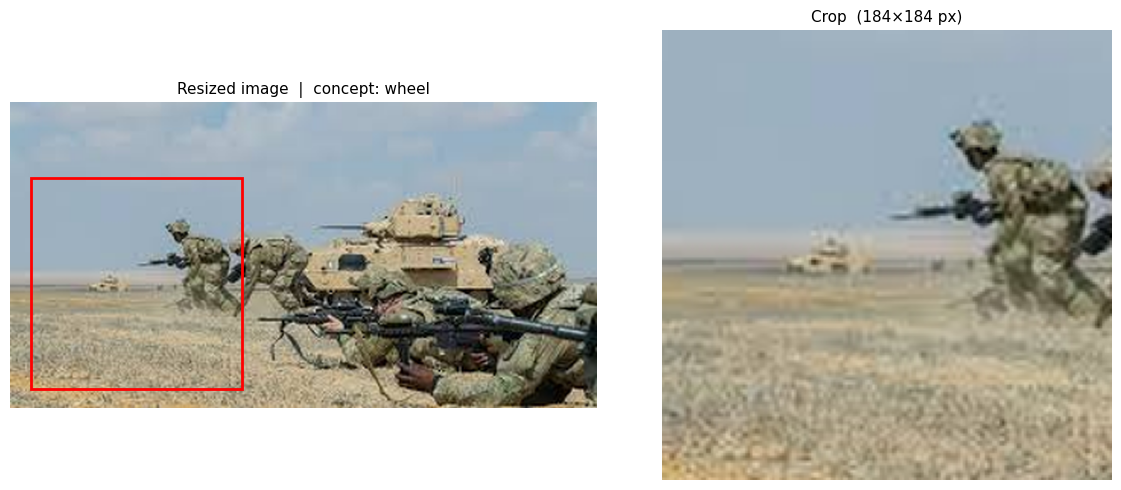

Crop size: (184, 184)


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

# ── 2. Select entry ───────────────────────────────────────────────────────────
CONCEPT_IDX = 4   # ← change this (0 to num_concepts-1)
IMAGE_IDX   = 3   # ← change this (0 to num_images_per_concept-1)

paths_all  = data1["image_grounding_paths"]
bboxes_all = data1["image_grounding_bboxes"]
preds_all  = data1["image_grounding_predictions"]
cnames     = data1["concept_names"]

img_path  = paths_all[CONCEPT_IDX][IMAGE_IDX]
bbox      = bboxes_all[CONCEPT_IDX][IMAGE_IDX]   # [x, y, w, h] in resized space
pred_label = preds_all[CONCEPT_IDX][IMAGE_IDX]
concept   = cnames[CONCEPT_IDX][IMAGE_IDX] if isinstance(cnames[0], list) else cnames[CONCEPT_IDX]

print(f"Concept [{CONCEPT_IDX}][{IMAGE_IDX}]: {concept}")
print(f"Image path : {img_path}")
print(f"BBox (x,y,w,h): {bbox}")
print(f"Stored label  : {pred_label}")

# ── 3. Resize image to stored bbox coordinate space, then crop ────────────────
full_img = Image.open(img_path).convert("RGB")
orig_w, orig_h = full_img.size
scale = IMAGE_SIZE_W / orig_w
new_h = int(round(orig_h * scale))
resized = full_img.resize((IMAGE_SIZE_W, new_h), Image.LANCZOS)

x, y, bw, bh = [int(v) for v in bbox]
x2, y2 = min(x + bw, IMAGE_SIZE_W), min(y + bh, new_h)
crop_img = resized.crop((x, y, x2, y2))

# ── Visualise original + bbox + crop ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(np.array(resized))
rect = mpatches.Rectangle((x, y), bw, bh, linewidth=2, edgecolor="red", facecolor="none")
axes[0].add_patch(rect)
axes[0].set_title(f"Resized image  |  concept: {concept}", fontsize=11)
axes[0].axis("off")

axes[1].imshow(np.array(crop_img))
axes[1].set_title(f"Crop  ({bw}×{bh} px)", fontsize=11)
axes[1].axis("off")

plt.tight_layout()
plt.show()

print(f"Crop size: {crop_img.size}")

In [6]:
import argparse
import torch
from models import get_model_class
from models.constants import TASK_PROMPTS

# ── 4. Load model from .env ───────────────────────────────────────────────────
print(f"Loading model: {VLM_MODEL}  (device={DEVICE}) ...")

_args = argparse.Namespace(
    local_files_only=False,
    cache_dir=HF_HOME,
    prompt_template=PROMPT_TMPL,
    prompt=PROMPT,
)

model_class = get_model_class(
    model_name_or_path=VLM_MODEL,
    processor_name=VLM_MODEL,
    device=DEVICE,
    args=_args,
)
print("Model loaded.")

Loading model: Qwen/Qwen2.5-VL-7B-Instruct  (device=cuda:0) ...


/mnt/abka03/.conda/envs/xlvlms/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading checkpoint shards: 100%|██████████| 5/5 [00:02<00:00,  2.09it/s]
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.
You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading 

Model loaded.


In [ ]:
import tempfile, re, json
import matplotlib.patches as patches

grounding_class = (
    "Classify the image as either [concept] or No [concept] based on its content. "
    "Answer with only one of these two options. And ground the output concept in the image "
    "by providing the bounding box coordinates of the detected concept in the format "
    "(x_min, y_min, x_max, y_max). If the concept is not present, return 'No [concept]' "
    "and provide empty bounding box coordinates (0, 0, 0, 0)."
)

# ── 5. Build prompt ───────────────────────────────────────────────────────────
_tmpl_prompt = TASK_PROMPTS.get(PROMPT_TMPL, {}).get("prompt", grounding_class)
if "[concept]" in _tmpl_prompt:
    instruction = _tmpl_prompt.replace("[concept]", concept)
else:
    instruction = PROMPT
print(f"Instruction: {instruction}")

# ── 6. Save crop to temp file ─────────────────────────────────────────────────
with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as tmp:
    tmp_path = tmp.name
crop_img.save(tmp_path)

# ── 7. Run inference ──────────────────────────────────────────────────────────
inputs = model_class.preprocessor_(
    instruction=instruction,
    image_file=tmp_path,
    generation_mode=True,
)
inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

with torch.no_grad():
    output_ids = model_class.model_.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=False,
    )

input_len = inputs["input_ids"].shape[1]
generated = output_ids[0][input_len:]
response  = model_class.tokenizer_.decode(generated, skip_special_tokens=True).strip()
os.unlink(tmp_path)

# ── 8. Parse bbox — handles all observed model output formats ─────────────────
def parse_bbox(text):
    # Strip markdown code fences so json.loads can parse cleanly
    clean = re.sub(r"```(?:json)?", "", text).strip()

    # Try JSON object — accepts bbox_2d, bounding_box, bbox, box keys
    json_match = re.search(r'\{.*?\}', clean, re.DOTALL)
    if json_match:
        try:
            obj = json.loads(json_match.group())
            for key in ("bbox_2d", "bounding_box", "bbox", "box"):
                val = obj.get(key)
                if isinstance(val, (list, tuple)) and len(val) == 4:
                    coords = tuple(float(v) for v in val)
                    if coords != (0.0, 0.0, 0.0, 0.0):
                        return coords
        except (json.JSONDecodeError, TypeError):
            pass

    # Fallback: bare [x, y, x2, y2] array in text
    m = re.search(r'\[\s*(\d+(?:\.\d+)?)\s*,\s*(\d+(?:\.\d+)?)\s*,\s*(\d+(?:\.\d+)?)\s*,\s*(\d+(?:\.\d+)?)\s*\]', clean)
    if m:
        coords = tuple(float(v) for v in m.groups())
        if coords != (0.0, 0.0, 0.0, 0.0):
            return coords

    # Fallback: (x_min, y_min, x_max, y_max) tuple syntax
    m = re.search(r'\(\s*(\d+(?:\.\d+)?)\s*,\s*(\d+(?:\.\d+)?)\s*,\s*(\d+(?:\.\d+)?)\s*,\s*(\d+(?:\.\d+)?)\s*\)', clean)
    if m:
        coords = tuple(float(v) for v in m.groups())
        if coords != (0.0, 0.0, 0.0, 0.0):
            return coords

    return None

pred_bbox = parse_bbox(response)
print(f"Model response : {response}")
print(f"Parsed bbox    : {pred_bbox}")

# ── 9. Display ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: crop with predicted bbox overlay
ax = axes[0]
ax.imshow(np.array(crop_img))
if pred_bbox is not None:
    x_min, y_min, x_max, y_max = pred_bbox
    rect = patches.Rectangle(
        (x_min, y_min), x_max - x_min, y_max - y_min,
        linewidth=2, edgecolor="lime", facecolor="none", label="model bbox"
    )
    ax.add_patch(rect)
    ax.legend(loc="upper right", fontsize=8)
ax.set_title("Crop + model bbox" if pred_bbox else "Crop (no bbox detected)", fontsize=11)
ax.axis("off")

# Right: text summary
short_prompt = instruction[:80] + "..." if len(instruction) > 80 else instruction
axes[1].axis("off")
summary = (
    f"Concept  : {concept}\n"
    f"Template : {PROMPT_TMPL}\n\n"
    f"Prompt   : {short_prompt}\n\n"
    f"Response : {response}\n\n"
    f"Bbox     : {pred_bbox}\n"
    f"Label    : {pred_label}"
)
axes[1].text(0.05, 0.95, summary, transform=axes[1].transAxes,
             fontsize=10, va="top", family="monospace",
             bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Stored label   : {pred_label}")